#  Machine Learning Fundamentals – Student Performance (Synthetic Dataset)

This notebook demonstrates the fundamental concepts of Machine Learning using a simple synthetic dataset.

---

##  Objectives

- Understand basic ML workflow  
- Learn how features affect predictions  
- Apply Linear Regression  
- Understand model evaluation metrics (MAE, R²)  
- Explore concepts like scaling and feature importance  

---

##  Why This Notebook?

Before working with real-world data, we first build intuition using a controlled dataset.

This helps in understanding:
- How features influence output  
- How models learn patterns  
- How evaluation metrics work  

---

##  Dataset Description

A synthetic dataset is created with the following features:

- **study_hours** → Hours spent studying  
- **attendance** → Class attendance percentage  
- **sleep_hours** → Daily sleep duration  
- **internet_usage** → Time spent on internet  
- **score** → Student performance score  

---

##  Important Note

This dataset is artificially created and highly structured.

 Real-world datasets are:
- Noisy  
- Less predictable  
- More complex  

This notebook serves as a **foundation for the next phase (real dataset analysis)**.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor

print("Setup successful")

Setup successful


In [5]:
# Creating dataset
data = {
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "attendance": [60, 65, 70, 75, 80, 85, 90, 95],
    "sleep_hours": [5, 6, 6, 7, 7, 8, 8, 8],
    "internet_usage": [6, 5, 5, 4, 4, 3, 3, 2],
    "score": [50, 55, 65, 70, 75, 85, 90, 95]
}

df = pd.DataFrame(data)

df

,study_hours,attendance,sleep_hours,internet_usage,score
0,1,60,5,6,50
1,2,65,6,5,55
2,3,70,6,5,65
3,4,75,7,4,70
4,5,80,7,4,75
5,6,85,8,3,85
6,7,90,8,3,90
7,8,95,8,2,95


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     8 non-null      int64
 1   attendance      8 non-null      int64
 2   sleep_hours     8 non-null      int64
 3   internet_usage  8 non-null      int64
 4   score           8 non-null      int64
dtypes: int64(5)
memory usage: 452.0 bytes


In [7]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,score
count,8.00000,8.000000,8.000000,8.000000,8.00000
mean,4.50000,77.500000,6.875000,4.000000,73.12500
std,2.44949,12.247449,1.125992,1.309307,16.24313
min,1.00000,60.000000,5.000000,2.000000,50.00000
25%,2.75000,68.750000,6.000000,3.000000,62.50000
50%,4.50000,77.500000,7.000000,4.000000,72.50000
75%,6.25000,86.250000,8.000000,5.000000,86.25000
max,8.00000,95.000000,8.000000,6.000000,95.00000


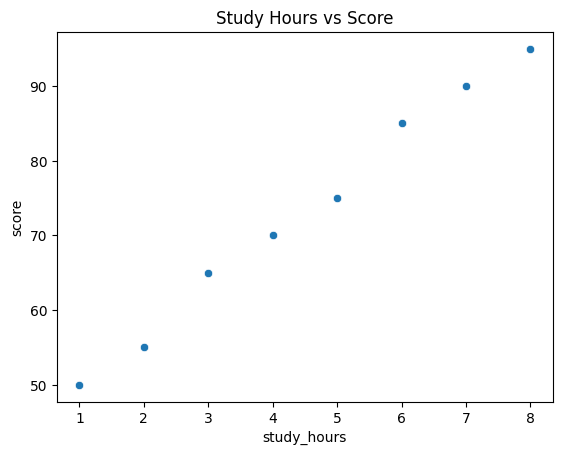

In [8]:
sns.scatterplot(x= "study_hours", y= "score", data = df)
plt.title("Study Hours vs Score")
plt.show()

In [9]:
df.corr()

,study_hours,attendance,sleep_hours,internet_usage,score
study_hours,1.000000,1.000000,0.958215,-0.979958,0.996368
attendance,1.000000,1.000000,0.958215,-0.979958,0.996368
sleep_hours,0.958215,0.958215,1.000000,-0.969003,0.961708
internet_usage,-0.979958,-0.979958,-0.969003,1.000000,-0.973999
score,0.996368,0.996368,0.961708,-0.973999,1.000000


study hours and attendance has the strongest positive effect on score.
internet ussage has the negative effect on the score.
if a student study hours is zero then score will be 50. (according to data).

In [10]:
#Features(X) and target(y)
X = df[["study_hours", "attendance", "sleep_hours", "internet_usage"]]
y = df["score"]
#split data (train = 80% and test = 20%)
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

In [11]:
#Train model
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
#Make predictions
y_pred = model.predict(X_test)

print("Predicted scores:", y_pred)
print("Actual scores:", y_test.values)

Predicted scores: [57. 83.]
Actual scores: [55 85]


In [13]:
#Evaluate model

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Absolute Error: 2.0
R-squared: 0.9822222222222222


Mean Absolute Error tells us about prediction error that is 2.0 that is prediction is off by ±2 marks, whereas r^2 score is 0.982 which indicates that 98.2% of the variance in student scores is explained by your model

In [14]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [0.25 1.25 1.   1.  ]
Intercept: -35.75


Increasing study hours by 1 hour increases score by 0.25 marks.

needs feature scaling because features are on different scale.
So we will use Z-standardisation.
Without Scaling model may give unfair importance to large-scale features.
Attendance has a large range in comparison.

In [15]:
#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Predicted scores (scaled):", y_pred_scaled)
print("Actual scores:", y_test.values)

Predicted scores (scaled): [57. 83.]
Actual scores: [55 85]


In [18]:
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print("MAE (scaled):", mae_scaled)
print("R2 Score (scaled):", r2_scaled)

MAE (scaled): 1.999999999999993
R2 Score (scaled): 0.9822222222222223


performance improved slightly. old mae = 2.0 and new mae = 1.9. old r^2 score was 0.982 and new one is still = 0.982.
i dont know why the scalling didnt drastically change results here.
scaling will become very important when data range is large. 


Random Forest Regressor -
it builds many decision trees and combines their prediction (ensemble learning)

In [19]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
y_pred_rf = rf_model.predict(X_test)

print("Predicted scores (Random Forest):", y_pred_rf)
print("Actual scores:", y_test.values)

Predicted scores (Random Forest): [59.45 84.2 ]
Actual scores: [55 85]


In [21]:
#Evaluate Random Forest model

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE (Random Forest):", mae_rf)
print("R2 Score (Random Forest):", r2_rf)

MAE (Random Forest): 2.625
R2 Score (Random Forest): 0.9545722222222222


We can come to conclusion that linear MAE (1.9) is better than Random Forest MAE (2.65) and R2 score (0.982) is better in Linear than R2 score (0.95) of Random Forest 

Linear Regression outperformed Random Forest because the dataset exhibited a strong linear relationship with minimal noise. Random Forest, being a more complex model, overfit the small dataset and failed to generalize better.

In [23]:
# Feature Importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance:\n", feature_importance)

Feature Importance:
 attendance        0.303437
study_hours       0.246601
sleep_hours       0.236832
internet_usage    0.213130
dtype: float64


hence attendance is ranked highest and internet_ussage is the least one. and it doesnt match my intuition because i predicted study hours will be ranked higher.
Reason 1: Small Dataset Problem
Reason 2: Features Are Correlated ( study_hours and attendance increasiong together)
    Random Forest:
    Splits importance between similar features
    May assign slightly higher weight to one arbitrarily
    Attendance got slightly higher importance than study_hours
Reason 3: Tree-Based Behavior
    If attendance creates slightly better splits: It gets higher importance

Although intuitively study hours should be most important, Random Forest ranked attendance higher due to feature correlation and the small dataset size. Tree-based models distribute importance among correlated features, which can lead to such variations.


Now we can focus on building Recommendation system:

In [24]:
def generate_recommendations(input_data):
    recommendations = []

    if input_data["study_hours"] < 3:
        recommendations.append("Increase study hours to atleast 3 hours per day.")
    if input_data["attendance"] < 75:
        recommendations.append("Improve attendance to atleast 75%.")
    if input_data["sleep_hours"] < 6:
        recommendations.append("Ensure atleast 6 hours of sleep per day.")
    if input_data["internet_usage"] > 4:
        recommendations.append("Reduce internet usage to less than 4 hours per day.")

    return recommendations

Testing (Rule based Recommendation System)

In [25]:
student = {
    "study_hours": 2,
    "attendance": 70,
    "sleep_hours": 5,
    "internet_usage": 6
}

generate_recommendations(student)

['Increase study hours to atleast 3 hours per day.',
 'Improve attendance to atleast 75%.',
 'Ensure atleast 6 hours of sleep per day.',
 'Reduce internet usage to less than 4 hours per day.']